
# Occupancy Prediction

## Exploratory Data Analysis


### Setup and Config

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

# -- ARGS --
data_training_path = Path("data/datatraining.txt")



### Data Loading

In this section, we load the training dataset and perform an initial inspection to understand its structure and contents.

In [ ]:

df = pd.read_csv(data_training_path)
df.head()


,date,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
1,2015-02-04 17:51:00,23.18,27.2720,426.0,721.25,0.004793,1
2,2015-02-04 17:51:59,23.15,27.2675,429.5,714.00,0.004783,1
3,2015-02-04 17:53:00,23.15,27.2450,426.0,713.50,0.004779,1
4,2015-02-04 17:54:00,23.15,27.2000,426.0,708.25,0.004772,1
5,2015-02-04 17:55:00,23.10,27.2000,426.0,704.50,0.004757,1


### Data Structure & Schema

In [ ]:
print(f"Data shape: {df.shape}")
print(f"Columns: {df.columns.to_list()}")

Data shape: (8143, 7)
Columns: ['date', 'Temperature', 'Humidity', 'Light', 'CO2', 'HumidityRatio', 'Occupancy']


### Datetime Parsing & Sorting

In [ ]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
na_dt = df["date"].isna().sum()
if na_dt:
    print(f"ERROR - {na_dt} unparsable dates -> NaT")
    
df = df.sort_values("date").reset_index(drop=True)
df.head()

,date,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
0,2015-02-04 17:51:00,23.18,27.2720,426.0,721.25,0.004793,1
1,2015-02-04 17:51:59,23.15,27.2675,429.5,714.00,0.004783,1
2,2015-02-04 17:53:00,23.15,27.2450,426.0,713.50,0.004779,1
3,2015-02-04 17:54:00,23.15,27.2000,426.0,708.25,0.004772,1
4,2015-02-04 17:55:00,23.10,27.2000,426.0,704.50,0.004757,1


### Data Quality

In [5]:
# duplicates
n_dupes = df.duplicated().sum()
print("Full-row duplicates:", n_dupes)

# Missing values
na_counts = df.isna().sum().sort_values(ascending=False)
na_pct = (df.isna().mean() * 100).round(3)
missing_report = pd.DataFrame({"missing_count": na_counts, "missing_pct": na_pct})
display(missing_report)

Full-row duplicates: 0


,missing_count,missing_pct
date,0,0.0
Temperature,0,0.0
Humidity,0,0.0
Light,0,0.0
CO2,0,0.0
HumidityRatio,0,0.0
Occupancy,0,0.0


### Simple Range Checks

In [6]:
checks = {}
if "Temperature" in df:
    checks['Temperature_out_of_range'] = int(((df['Temperature'] < -10) | (df['Temperature'] > 50)).sum())
if "Humidity" in df:
    checks['Humidity_out_of_range'] = int(((df['Humidity'] < 0) | (df['Humidity'] > 100)).sum())
if "Light" in df:
    checks['Light_negative'] = int((df['Light'] < 0).sum())
if "CO2" in df:
    checks['CO2_out_of_range'] = int(((df['CO2'] < 200) | (df['CO2'] > 10000)).sum())
if "HumidityRatio" in df:
    checks['HumidityRatio_negative'] = int((df['HumidityRatio'] < 0).sum())
checks

{'Temperature_out_of_range': 0,
 'Humidity_out_of_range': 0,
 'Light_negative': 0,
 'CO2_out_of_range': 0,
 'HumidityRatio_negative': 0}

### Descriptive Statistics

In [ ]:
numeric_cols = [col for col in df.columns if col != "Occupancy" and pd.api.types.is_numeric_dtype(df[col])]
df[numeric_cols + (["Occupancy"] if "Occupancy" in df else [])].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])

,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
count,8143.000000,8143.000000,8143.000000,8143.000000,8143.000000,8143.000000
mean,20.619084,25.731507,119.519375,606.546243,0.003863,0.212330
std,1.016916,5.531211,194.755805,314.320877,0.000852,0.408982
min,19.000000,16.745000,0.000000,412.750000,0.002674,0.000000
1%,19.200000,17.185500,0.000000,421.000000,0.002696,0.000000
5%,19.290000,18.600000,0.000000,428.000000,0.002730,0.000000
25%,19.700000,20.200000,0.000000,439.000000,0.003078,0.000000
50%,20.390000,26.222500,0.000000,453.500000,0.003801,0.000000
75%,21.390000,30.533333,256.375000,638.833333,0.004352,0.000000
95%,22.390000,34.422000,480.666667,1293.675000,0.005336,1.000000


### Feature Ranges (Quick Overview)

This section summarizes the ranges of the numeric features and the most frequent values for any non-numeric columns to quickly assess plausible value bounds.


In [ ]:
from typing import List

# Compute numeric ranges and simple categorical summaries
summary_rows: List[dict] = []
for col in df.columns:
    s = df[col]
    if pd.api.types.is_numeric_dtype(s):
        desc = s.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
        summary_rows.append({
            'column': col,
            'dtype': str(s.dtype),
            'min': float(desc['min']) if 'min' in desc else None,
            'p01': float(desc['1%']) if '1%' in desc else None,
            'p05': float(desc['5%']) if '5%' in desc else None,
            'p25': float(desc['25%']) if '25%' in desc else None,
            'median': float(desc['50%']) if '50%' in desc else None,
            'p75': float(desc['75%']) if '75%' in desc else None,
            'p95': float(desc['95%']) if '95%' in desc else None,
            'p99': float(desc['99%']) if '99%' in desc else None,
            'max': float(desc['max']) if 'max' in desc else None,
            'na_pct': float(s.isna().mean()*100.0)
        })

num_summary_df = pd.DataFrame(summary_rows)
if not num_summary_df.empty:
    display(num_summary_df.set_index('column'))

# For any non-numeric columns, show top categories
cat_info = {}
for col in df.columns:
    s = df[col]
    if not pd.api.types.is_numeric_dtype(s):
        vc = s.value_counts(dropna=False).head(10)
        cat_info[col] = vc

if cat_info:
    print("\nTop categories (up to 10) per non-numeric column:")
    for col, vc in cat_info.items():
        print(f"\n- {col}:")
        print(vc.to_string())


,dtype,min,p01,p05,p25,median,p75,p95,p99,max,na_pct
column,,,,,,,,,,,
Temperature,float64,19.000000,19.200000,19.29000,19.700000,20.390000,21.390000,22.390000,23.000000,23.180000,0.0
Humidity,float64,16.745000,17.185500,18.60000,20.200000,26.222500,30.533333,34.422000,38.617500,39.117500,0.0
Light,float64,0.000000,0.000000,0.00000,0.000000,0.000000,256.375000,480.666667,545.645000,1546.333333,0.0
CO2,float64,412.750000,421.000000,428.00000,439.000000,453.500000,638.833333,1293.675000,1950.750000,2028.500000,0.0
HumidityRatio,float64,0.002674,0.002696,0.00273,0.003078,0.003801,0.004352,0.005336,0.006373,0.006476,0.0
Occupancy,int64,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.0



Top categories (up to 10) per non-numeric column:

- date:
date
2015-02-04 17:51:00    1
2015-02-08 12:15:00    1
2015-02-08 12:28:00    1
2015-02-08 12:27:00    1
2015-02-08 12:26:00    1
2015-02-08 12:24:59    1
2015-02-08 12:23:59    1
2015-02-08 12:23:00    1
2015-02-08 12:22:00    1
2015-02-08 12:21:00    1


### Class balance

Counts:
 Occupancy
0    6414
1    1729

Ratios:
 Occupancy
0    0.788
1    0.212


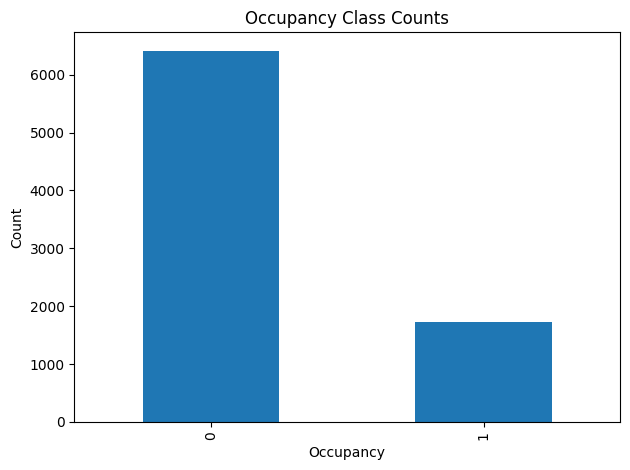

In [9]:
cls_counts = df["Occupancy"].value_counts(dropna=False).sort_index()
cls_ratio = (cls_counts / cls_counts.sum()).round(3)
print("Counts:\n", cls_counts.to_string())
print("\nRatios:\n", cls_ratio.to_string())
cls_counts.plot(kind="bar", title="Occupancy Class Counts")
plt.xlabel("Occupancy"); plt.ylabel("Count"); plt.tight_layout(); plt.show()

### Time-based features & patterns

In [10]:
df.set_index("date", inplace=True)
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['is_weekend'] = df['dayofweek'] >= 5

by_hour_of_day = (
    df.groupby('hour', as_index=False)['Occupancy']
      .mean()
      .rename(columns={'Occupancy': 'occ_mean'})
)

by_dow_hour = (
    df.groupby(['dayofweek','hour'], as_index=False)['Occupancy']
      .mean()
      .rename(columns={'Occupancy': 'occ_mean'})
)

#### Average Occupancy by Hour of Day


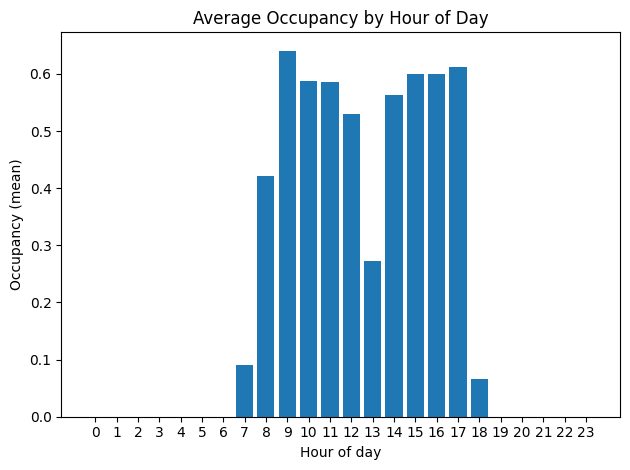

In [11]:
plt.figure()
plt.bar(by_hour_of_day['hour'], by_hour_of_day['occ_mean'])
plt.xticks(range(0, 24))
plt.xlabel('Hour of day')
plt.ylabel('Occupancy (mean)')
plt.title('Average Occupancy by Hour of Day')
plt.tight_layout(); plt.show()

#### Average Occupancy by Hour: Weekday vs Weekend



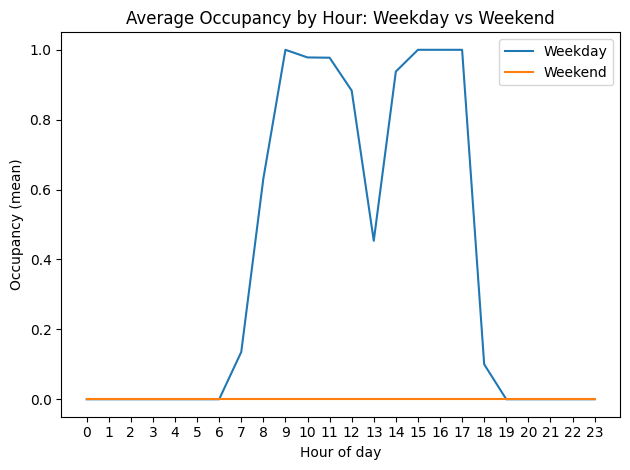

In [12]:
dow_hour_piv = (
    df.groupby(['is_weekend', 'hour'])['Occupancy'].mean()
      .unstack('is_weekend')
      .rename(columns={False: 'Weekday', True: 'Weekend'})
      .reindex(range(24))
)

plt.figure()
plt.plot(dow_hour_piv.index, dow_hour_piv['Weekday'], label='Weekday')
plt.plot(dow_hour_piv.index, dow_hour_piv['Weekend'], label='Weekend')
plt.xticks(range(0,24))
plt.xlabel('Hour of day')
plt.ylabel('Occupancy (mean)')
plt.title('Average Occupancy by Hour: Weekday vs Weekend')
plt.legend(); plt.tight_layout(); plt.show()


#### Mean Occupancy by Day of Week and Hour (Heatmap)


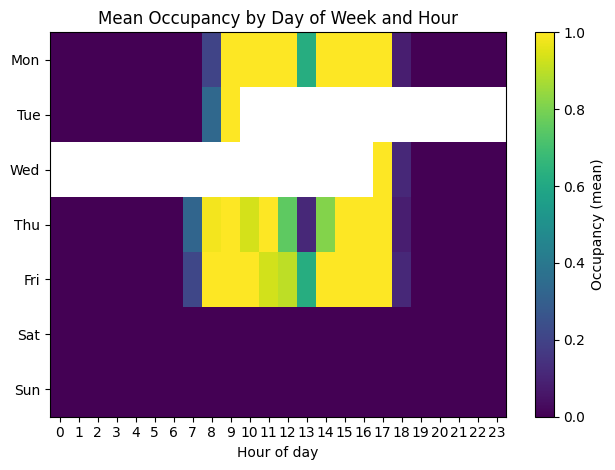

In [13]:
heat = (
    by_dow_hour
    .pivot_table(index='dayofweek', columns='hour', values='occ_mean', aggfunc='mean')
    .reindex(index=range(7), columns=range(24))
)

plt.figure()
im = plt.imshow(heat, aspect='auto', interpolation='nearest')
plt.colorbar(im, label='Occupancy (mean)')
plt.yticks(ticks=range(7), labels=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
plt.xticks(ticks=range(0,24,1))
plt.xlabel('Hour of day')
plt.title('Mean Occupancy by Day of Week and Hour')
plt.tight_layout(); plt.show()


## Conclusion for `data/datatraining.txt`

- **Dataset**: 8,143 rows × 7 columns (`date`, `Temperature`, `Humidity`, `Light`, `CO2`, `HumidityRatio`, `Occupancy`)
- **Duplicates**: 0 full-row duplicates detected.
- **Missingness**: No data missingness.
- **Class balance**: Occupancy is imbalanced — `0`: 6,414 (78.8%), `1`: 1,729 (21.2%). Evaluation should account for this (beyond raw accuracy).
- **Temporal patterns**:
  - Occupancy is substantially higher during work hours on weekdays; weekends are lower/flatter.
  - Heatmap by day-of-week × hour confirms strong daily/weekly seasonality.
- **Feature signals (qualitative)**: `Light` and `CO2` exhibit shifts around occupied periods; simple rolling means/differences were engineered and are likely predictive.


## ML Pipeline


In [14]:
from dataclasses import dataclass
from pathlib import Path
import json
import joblib
import csv
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_recall_curve,
     precision_score, recall_score, f1_score, confusion_matrix
)

from typing import Iterable, Tuple, Optional, List, Dict
from sklearn.base import clone

DATA_DIR = Path("data")
ARTIFACT_DIR = Path("out_logreg")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42


In [15]:
### Load Train/Test Datasets


EXPECTED_COLUMNS: Tuple[str, ...] = (
    "date", "Temperature", "Humidity", "Light", "CO2", "HumidityRatio", "Occupancy"
)

NUMERIC_FEATURES_DEFAULT: Tuple[str, ...] = (
    "Temperature", "Humidity", "Light", "CO2", "HumidityRatio"
)

def _coerce_numeric(df: pd.DataFrame, cols: Iterable[str]) -> None:
    """In-place: make columns numeric with NaNs on bad values and memory-friendly dtypes."""
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce", downcast="float")
    
def _validate_cols(df: pd.DataFrame, expected: Iterable[str]) -> None:
    missing = [c for c in expected if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required column(s): {missing}. Found: {list(df.columns)}")

def read_occ(
    path: Path,
    *,
    expected_columns: Iterable[str] = EXPECTED_COLUMNS,
    numeric_features: Iterable[str] = NUMERIC_FEATURES_DEFAULT,
    date_col: str = "date",
    sort: bool = True,
) -> pd.DataFrame:
    """
    Robust CSV reader for the Occupancy dataset family.

    - Auto-detects delimiter.
    - Parses `date` with tolerant casting.
    - Coerces numeric features and downcasts to save memory.
    - Ensures `Occupancy` is Int8 (nullable) and last-column typos don't break loading.
    - Validates the schema.
    """
    
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")
    
    df = pd.read_csv(
        path,
        engine="python",
        sep=None, # infer delimeter
        skipinitialspace=True,
        na_values=["", "NA", "NAN", "?", "null", "None"],
        quoting=csv.QUOTE_MINIMAL,
        on_bad_lines="warn"
    )
    df.columns = [c.strip() for c in df.columns]
    _validate_cols(df, expected_columns)
    
    if date_col in df.columns:
        df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    else:
        raise ValueError(f"Expected datetime column '{date_col}' not found.")

    _coerce_numeric(df, numeric_features)
    
    if "Occupancy" in df.columns:
        df["Occupancy"] = pd.to_numeric(df["Occupancy"], errors="coerce").astype("Int8")    
    
    if sort:
        df = df.sort_values(date_col, kind="mergesort").reset_index(drop=True)
    
    return df
    
def load_occ_datasets(
    train_path: Path,
    test1_path: Path,
    test2_path: Path
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    train_df = read_occ(train_path)
    test1_df = read_occ(test1_path)
    test2_df = read_occ(test2_path)
    return train_df, test1_df, test2_df

train_path = DATA_DIR / "datatraining.txt"
test1_path = DATA_DIR / "datatest.txt"
test2_path = DATA_DIR / "datatest2.txt"

train_df, test1_df, test2_df = load_occ_datasets(train_path, test1_path, test2_path)
print(train_df.shape, test1_df.shape, test2_df.shape)
display(train_df.head())


(8143, 7) (2665, 7) (9752, 7)


,date,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
0,2015-02-04 17:51:00,23.18,27.271999,426.0,721.25,0.004793,1
1,2015-02-04 17:51:59,23.15,27.267500,429.5,714.00,0.004783,1
2,2015-02-04 17:53:00,23.15,27.245001,426.0,713.50,0.004779,1
3,2015-02-04 17:54:00,23.15,27.200001,426.0,708.25,0.004772,1
4,2015-02-04 17:55:00,23.10,27.200001,426.0,704.50,0.004757,1


In [16]:
# Add time features

def add_time_features(
    df: pd.DataFrame,
    *,
    date_col: str = "date",
    make_cyclic: bool = True,
    weekend_as_int: bool = True,
) -> pd.DataFrame:
    """
    Add hour/dayofweek/is_weekend; optionally add cyclic encodings.
    Works in-place and returns df for chaining.
    """
    if date_col not in df:
        return df

    dt = df[date_col].dt
    
    if "hour" not in df:
        df["hour"] = dt.hour
    if "dayofweek" not in df:
        df["dayofweek"] = dt.dayofweek
    if "is_weekend" not in df:
        df["is_weekend"] = (dt.dayofweek >= 5)
    
    if weekend_as_int:
        df["is_weekend"] = df["is_weekend"].astype("uint8")
    
    # Cycling encodings (often outperform raw hour/dow for linear models)
    if make_cyclic:
        if "hour_sin" not in df:
            df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24.0)
        if "hour_cos" not in df:
            df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24.0)
        if "dow_sin" not in df:
            df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7.0)
        if "dow_cos" not in df:
            df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7.0)
    return df

def _numeric_like(series: pd.Series) -> bool:
    """True for numeric or boolean (so bools become features)."""
    return pd.api.types.is_numeric_dtype(series) or pd.api.types.is_bool_dtype(series)

def build_feature_target(
    df: pd.DataFrame,
    *,
    target_col: str = "Occupancy",
    drop_cols: Iterable[str] = ("date",),     # columns to exclude even if numeric
    use_columns: Optional[Iterable[str]] = None,  # fixed feature list (for test splits)
) -> Tuple[pd.DataFrame, np.ndarray, List[str]]:
    """
    Build (X, y, feat_cols) with sensible dtypes and no leakage.
    - Selects numeric/boolean features except target & drop_cols.
    - Returns X as DataFrame (so you retain column names).
    """
    for c in df.columns:
        if pd.api.types.is_bool_dtype(df[c]):
            df[c] = df[c].astype("uint8")
        
        if use_columns is None:
            base_features = [
                c for c in df.columns
                if c != target_col
                and c not in set(drop_cols)
                and _numeric_like(df[c])
            ]
        else:
            base_features = list(use_columns)
        
    X = df[base_features].copy()
    for c in X.columns:
        if pd.api.types.is_float_dtype(X[c]):
            X[c] = pd.to_numeric(X[c], downcast="float")
        elif pd.api.types.is_integer_dtype(X[c]):
            X[c] = pd.to_numeric(X[c], downcast="integer")
    
    y = df[target_col].astype(int).to_numpy()
    return X, y, base_features
        
def align_and_impute_like_train(
    X_train: pd.DataFrame,
    *X_tests: pd.DataFrame
) -> Tuple[pd.DataFrame, ...]:
    """
    Reindex tests to train columns and impute NaNs with train medians.
    Returns (X_train_filled, *X_tests_filled)
    """
    train_cols = X_train.columns
    train_medians = X_train.median(numeric_only=True)
    def _fix(X: pd.DataFrame) -> pd.DataFrame:
        Z = X.reindex(columns=train_cols)
        Z = Z.copy()
        for c in train_cols:
            if pd.api.types.is_numeric_dtype(Z[c]):
                Z[c] = Z[c].fillna(train_medians.get(c, 0))
            else:
                Z[c] = Z[c].fillna(0)
        return Z
    fixed = [_fix(df) for df in (X_train, *X_tests)]
    return tuple(fixed)

In [17]:
for _df in (train_df, test1_df, test2_df):
    add_time_features(_df, make_cyclic=True, weekend_as_int=True)

X_train, y_train, feat_cols = build_feature_target(
    train_df,
    target_col="Occupancy",
    drop_cols=("date",),     # prevents raw datetime leakage
)

# Build test matrices using the *same* feature list
X_test1, y_test1, _ = build_feature_target(
    test1_df, target_col="Occupancy", drop_cols=("date",), use_columns=feat_cols
)
X_test2, y_test2, _ = build_feature_target(
    test2_df, target_col="Occupancy", drop_cols=("date",), use_columns=feat_cols
)

X_train, X_test1, X_test2 = align_and_impute_like_train(X_train, X_test1, X_test2)

assert list(X_train.columns) == feat_cols
assert list(X_test1.columns) == feat_cols
assert list(X_test2.columns) == feat_cols

feat_cols

['Temperature',
 'Humidity',
 'Light',
 'CO2',
 'HumidityRatio',
 'hour',
 'dayofweek',
 'is_weekend',
 'hour_sin',
 'hour_cos',
 'dow_sin',
 'dow_cos']

In [18]:
# Pipeline with caching (faster grid search when re-running)

memor

NameError: name 'memor' is not defined

In [ ]:
C_grid = np.logspace(-3, 3, 7)
param_grid = [
    {
        "clf__solver": ["liblinear"],
        "clf__penalty": ["l1", "l2"],
        "clf__C": C_grid,
    },
    {
        "clf__solver": ["saga"],
        "clf__penalty": ["l1", "l2", "elasticnet"],
        "clf__l1_ratio": [0.1, 0.5, 0.9],  # only used when penalty='elasticnet'
        "clf__C": C_grid,
    },
]

# Time-series-aware CV on training set only
cv = TimeSeriesSplit(n_splits=5, gap=5)
    
scoring = {
    "average_precision": "average_precision",
    "roc_auc": "roc_auc",
    "f1": "f1",
    "recall": "recall",
    "precision": "precision",
}

gs = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=cv,
    scoring=scoring,
    refit="average_precision",
    n_jobs=-1,
    verbose=1,
    return_train_score=False,
    error_score="raise",
)

try:
    gs.fit(X_train, y_train)
except Exception as e:
    print(f"Grid search failed: {e}")
    
print("Best params:", gs.best_params_)
print("Best CV AP:", gs.best_score_)


In [ ]:
best_pipe = gs.best_estimator_


,steps,"[('scaler', ...), ('clf', ...)]"
,transform_input,None
,memory,Memory(locati...sk_mem/joblib)
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,np.float64(0.1)


In [ ]:
best_pipe

In [ ]:

# Generate predictions on test sets
y_prob_test1 = best_pipe.predict_proba(X_test1)[:, 1]
y_prob_test2 = best_pipe.predict_proba(X_test2)[:, 1]

print("Predictions generated successfully!")
print(f"Test1 probabilities shape: {y_prob_test1.shape}")
print(f"Test2 probabilities shape: {y_prob_test2.shape}")
print(f"Test1 probability range: [{y_prob_test1.min():.4f}, {y_prob_test1.max():.4f}]")
print(f"Test2 probability range: [{y_prob_test2.min():.4f}, {y_prob_test2.max():.4f}]")


Predictions generated successfully!
Test1 probabilities shape: (2665,)
Test2 probabilities shape: (9752,)
Test1 probability range: [0.0055, 1.0000]
Test2 probability range: [0.0001, 1.0000]


In [ ]:
def select_optimal_threshold(
    y_true: np.ndarray,
    y_proba: np.ndarray, 
    metric: str = 'f1' # {f1, precision, recall}
    ) -> Tuple[float, Dict]:
    """
    Pick a threshold using precision-recall curve.
    Returns (threshold, metrics_dict).
    """
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    
    # Handle degenerate case: no thresholds (constant proba)
    if thresholds.size == 0:
        t = 0.5
        y_hat = (y_proba >= t).astype(int)
        tp = np.sum((y_hat == 1) & (y_true == 1))
        fp = np.sum((y_hat == 1) & (y_true == 0))
        fn = np.sum((y_hat == 0) & (y_true == 1))
        p = tp / (tp + fp + 1e-12)
        r = tp / (tp + fn + 1e-12)
        f1 = 2 * p * r / (p + r + 1e-12)
        return t, {"threshold": t, "precision": p, "recall": r, "f1": f1}
    
    p = precision[1:]
    r = recall[1:]
    
    if metric == "f1":
        f1 = 2 * p * r / (p + r + 1e-12)
        i = int(np.nanargmax(f1))
    elif metric == "precision":
        i = int(np.nanargmax(p))
    elif metric == "recall":
        i = int(np.nanargmax(r))
    else:
        raise ValueError("metric must be 'f1', 'precision', or 'recall'")

    t = float(thresholds[i])
    metrics = {
        "threshold": t,
        "precision": float(p[i]),
        "recall": float(r[i]),
        "f1": float(2 * p[i] * r[i] / (p[i] + r[i] + 1e-12)),
    }
    return t, metrics

# Select threshold using training set
optimal_threshold, train_metrics = select_optimal_threshold(y_train, best_pipe.predict_proba(X_train)[:, 1])

print(f"Optimal threshold: {optimal_threshold:.4f}")
print(f"Training set - Precision: {train_metrics['precision']:.4f}, "
      f"Recall: {train_metrics['recall']:.4f}, F1: {train_metrics['f1']:.4f}")


Optimal threshold: 0.4982
Training set - Precision: 0.9505, Recall: 0.9988, F1: 0.9741


In [ ]:

def evaluate_model_performance(y_true, y_prob, threshold, dataset_name):
    """Comprehensive model evaluation."""
    
    
    y_pred = (y_prob >= threshold).astype(int)
    
    metrics = {
        'dataset': dataset_name,
        'threshold': float(threshold),
        'average_precision': float(average_precision_score(y_true, y_prob)),
        'roc_auc': float(roc_auc_score(y_true, y_prob)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'f1_score': float(f1_score(y_true, y_pred, zero_division=0)),
        'accuracy': float((y_pred == y_true).mean()),
        'confusion_matrix': confusion_matrix(y_true, y_pred).tolist()
    }
    
    print(f"\n=== {dataset_name.upper()} PERFORMANCE ===")
    print(f"Threshold: {threshold:.4f}")
    print(f"Average Precision: {metrics['average_precision']:.4f}")
    print(f"ROC AUC: {metrics['roc_auc']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall: {metrics['recall']:.4f}")
    print(f"F1 Score: {metrics['f1_score']:.4f}")
    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"Confusion Matrix:\n{confusion_matrix(y_true, y_pred)}")
    
    return metrics

# Evaluate on both test sets
test1_metrics = evaluate_model_performance(y_test1, y_prob_test1, optimal_threshold, "Test Set 1")
test2_metrics = evaluate_model_performance(y_test2, y_prob_test2, optimal_threshold, "Test Set 2")



=== TEST SET 1 PERFORMANCE ===
Threshold: 0.4982
Average Precision: 0.9740
ROC AUC: 0.9918
Precision: 0.9455
Recall: 0.9990
F1 Score: 0.9715
Accuracy: 0.9786
Confusion Matrix:
[[1637   56]
 [   1  971]]

=== TEST SET 2 PERFORMANCE ===
Threshold: 0.4982
Average Precision: 0.9779
ROC AUC: 0.9963
Precision: 0.9542
Recall: 0.9966
F1 Score: 0.9749
Accuracy: 0.9892
Confusion Matrix:
[[7605   98]
 [   7 2042]]


Plots saved to: out_logreg/roc_pr_curves.png


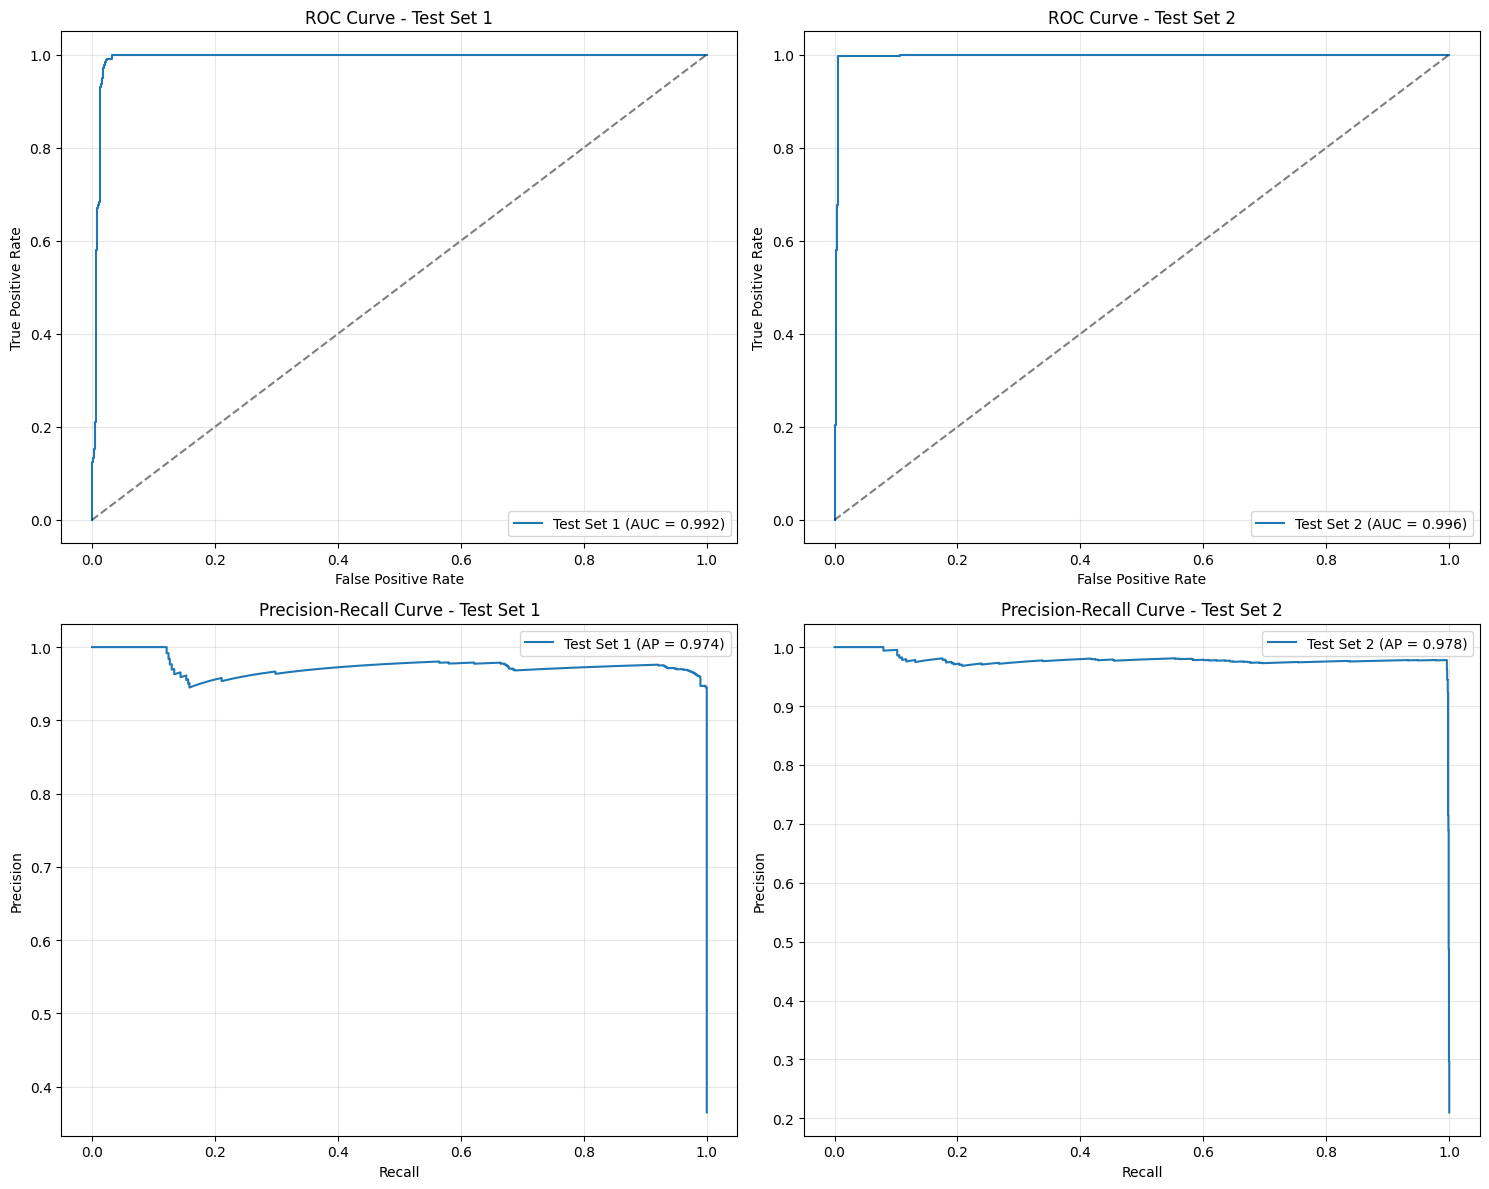

In [ ]:
# Create visualizations
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

def plot_roc_curve(y_true, y_prob, dataset_name, ax):
    """Plot ROC curve."""
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    
    ax.plot(fpr, tpr, label=f'{dataset_name} (AUC = {auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve - {dataset_name}')
    ax.legend()
    ax.grid(True, alpha=0.3)

def plot_precision_recall_curve(y_true, y_prob, dataset_name, ax):
    """Plot Precision-Recall curve."""
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)
    
    ax.plot(recall, precision, label=f'{dataset_name} (AP = {ap:.3f})')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'Precision-Recall Curve - {dataset_name}')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Create subplots for ROC and PR curves
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# ROC curves
plot_roc_curve(y_test1, y_prob_test1, "Test Set 1", axes[0, 0])
plot_roc_curve(y_test2, y_prob_test2, "Test Set 2", axes[0, 1])

# Precision-Recall curves
plot_precision_recall_curve(y_test1, y_prob_test1, "Test Set 1", axes[1, 0])
plot_precision_recall_curve(y_test2, y_prob_test2, "Test Set 2", axes[1, 1])

plt.tight_layout()

# Save plots before showing
plt.savefig(ARTIFACT_DIR / "roc_pr_curves.png", dpi=300, bbox_inches='tight')
print(f"Plots saved to: {ARTIFACT_DIR / 'roc_pr_curves.png'}")

plt.show()


In [ ]:
# Save model and artifacts
import json
from pathlib import Path
from datetime import datetime

# Save the best pipeline
model_path = ARTIFACT_DIR / "logreg_best_pipeline.joblib"
joblib.dump(best_pipe, model_path)
print(f"Model saved to: {model_path}")

# Save model information
model_info = {
    "model_type": "LogisticRegression",
    "best_params": {k: float(v) if isinstance(v, (np.float64, np.float32)) else v 
                   for k, v in gs.best_params_.items()},
    "best_cv_score": float(gs.best_score_),
    "optimal_threshold": float(optimal_threshold),
    "feature_columns": feat_cols,
    "training_samples": len(X_train),
    "test1_samples": len(X_test1),
    "test2_samples": len(X_test2),
    "created_at": datetime.now().isoformat(),
    "random_seed": SEED
}

with open(ARTIFACT_DIR / "model_info.json", "w") as f:
    json.dump(model_info, f, indent=2)
print(f"Model info saved to: {ARTIFACT_DIR / 'model_info.json'}")

# Save evaluation metrics
all_metrics = {
    "test1_metrics": test1_metrics,
    "test2_metrics": test2_metrics,
    "training_metrics": {
        "precision": float(train_metrics["precision"]),
        "recall": float(train_metrics["recall"]),
        "threshold": float(optimal_threshold)
    }
}

with open(ARTIFACT_DIR / "metrics.json", "w") as f:
    json.dump(all_metrics, f, indent=2)
print(f"Metrics saved to: {ARTIFACT_DIR / 'metrics.json'}")

# Plots are saved in the previous cell

print(f"\nAll artifacts saved to: {ARTIFACT_DIR}")
print(f"- Model: logreg_best_pipeline.joblib")
print(f"- Info: model_info.json")
print(f"- Metrics: metrics.json")
print(f"- Plots: roc_pr_curves.png")


Model saved to: out_logreg/logreg_best_pipeline.joblib
Model info saved to: out_logreg/model_info.json
Metrics saved to: out_logreg/metrics.json

All artifacts saved to: out_logreg
- Model: logreg_best_pipeline.joblib
- Info: model_info.json
- Metrics: metrics.json
- Plots: roc_pr_curves.png
